<a href="https://colab.research.google.com/github/nicholas-schwier-class/Stats-Sum-26/blob/main/Class_10_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd

from scipy import stats

In [11]:
np.random.seed(42)

scores = np.random.normal(
                loc=78,
                scale=5,
                size=30)

print(scores)

[80.48357077 77.30867849 81.23844269 85.61514928 76.82923313 76.82931522
 85.89606408 81.83717365 75.65262807 80.71280022 75.68291154 75.67135123
 79.20981136 68.43359878 69.37541084 75.18856235 72.9358444  79.57123666
 73.45987962 70.93848149 85.32824384 76.8711185  78.33764102 70.87625907
 75.27808638 78.55461295 72.24503211 79.87849009 74.99680655 76.54153125]


Get descriptive stats WHATS THE MEAN OF THE SCORES?

In [12]:
score_df = pd.DataFrame(scores)

score_df.describe()

,0
count,30.000000
mean,77.059266
std,4.500032
min,68.433599
25%,75.044746
50%,76.829274
75%,79.801677
max,85.896064


One Sample t-Test

Question:

Is the mean score significantly different from 75?

Hypotheses

H₀: μ =75

Hₐ: μ≠75

In [13]:
t_statistic, p_value = stats.ttest_1samp(
                            scores,
                            popmean=75)

print("T Statistic =",t_statistic)

print("P-value =",p_value)

T Statistic = 2.506440272565388
P-value = 0.018054505756328387


In [14]:
alpha = 0.05


if p_value < alpha:

    print("Reject Null Hypothesis")

else:

    print("Fail to Reject Null")

Reject Null Hypothesis


Confidence Intervals

In [15]:
se = stats.sem(scores)
mean = np.mean(scores)

ci = stats.t.interval(

confidence=0.95,

df=len(scores)-1,

loc=mean,

scale=se

)

print(ci)

(np.float64(75.37892590517583), np.float64(78.73960513631377))


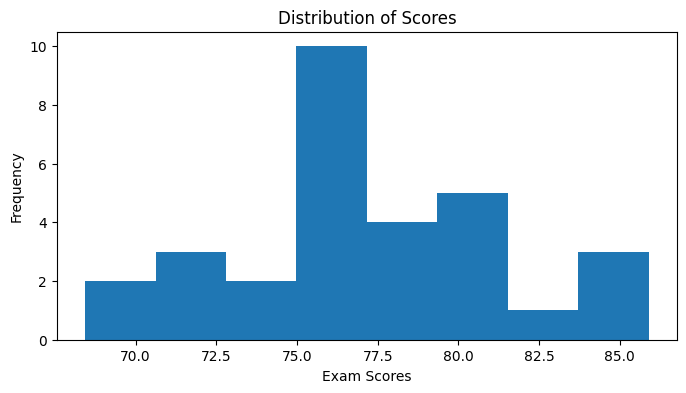

In [16]:
import matplotlib.pyplot as plt


plt.figure(figsize=(8,4))


plt.hist(scores,
         bins=8)


plt.xlabel("Exam Scores")

plt.ylabel("Frequency")

plt.title("Distribution of Scores")


plt.show()

In [22]:
def one_sample_test(data,hyp_mean):

    t,p = stats.ttest_1samp(
                    data,
                    hyp_mean)

    print("t =",round(t,3))
    print("p =",round(p,4))

    if p < .05:
        print("Reject H0")

    else:
        print("Fail to Reject H0")

one_sample_test(scores,75)

t = 2.506
p = 0.0181
Reject H0


Independent Samples t-Test

Research Question:

Do two classes perform differently?

In [20]:
A=np.array([70,72,74,75,77])
B=np.array([78,80,82,79,81])

t,p = stats.ttest_ind(
                    A,
                    B)

print(t)
print(p)

if p < .05:
    print("Groups differ")

else:
    print("No difference")

-4.571428571428576
0.001822370723477544
Groups differ


Paired t-Test

Example:

Pre-test and post-test scores

In [9]:
pre=np.array([70,72,68,75,71])

post=np.array([75,76,74,80,77])

stats.ttest_rel(pre,post)

TtestResult(statistic=np.float64(-13.89758457944607), pvalue=np.float64(0.00015543552359874096), df=np.int64(4))

Question 3

Which test compares before and after measurements?

A) Independent t-test

B) Paired t-test

C) ANOVA

D) Chi-square

Answer:

B

Testing Proportions

Question:

Did more than 60% of students pass?

Suppose:

48 passed

20 failed

In [10]:
from statsmodels.stats.proportion import proportions_ztest

count=48
nobs=68


stat,p = proportions_ztest(
count,
nobs,
value=.60
)

print(p)

0.05533374865492353


Coding Challenge 1: One-Sample Hypothesis Testing Investigation

Objective

Students will conduct a complete one-sample hypothesis test using Python and interpret the results.

Scenario

A professor claims that the average time students spend studying each week is 15 hours.

A sample of 25 students is collected.

Step 1: Generate Data

Generate 25 observations from a normal distribution with:

Mean = 17
Standard Deviation = 4

Use a random seed of 123.

Step 2: Compute Descriptive Statistics

Calculate:

Sample mean

Median

Standard deviation

Minimum

Maximum

Step 3: Conduct a One-Sample t-Test

Test:

H₀: μ = 15

Hₐ: μ ≠ 15

Step 4: Decision Making

Write an if statement that:

Rejects H₀ if p < .05
Otherwise fails to reject H₀

Step 5: Visualization

Create a histogram showing the distribution of study hours.

Add:

Title
X-axis label
Y-axis label

Coding Challenge 2: Comparing Two Teaching Methods

Objective

Compare two independent samples using Python.

Scenario

An instructor wants to compare test scores from two sections.

Section A uses traditional lectures.

Section B uses active learning.

Step 1: Generate Data

Step 2: Descriptive Statistics

Calculate for both groups:

Mean

Median

Standard deviation

Visual Exploration

Create histograms for both sections.

Questions:

Which section appears stronger?

Are there possible outliers?

Do distributions overlap?

Step 4: Independent Samples t-Test

Conduct

Test

H₀: μA = μB

Hₐ: μA ≠ μB

Step 5: Decision Statement

Coding Challenge 3: Build Your Own Hypothesis Testing Function

Part A: Create a Function

Write a function named hypothesis_test()

Inputs:

data

hypothesized_mean

alpha

unction Requirements

The function should:

Calculate

Mean

Standard deviation

t-statistic

p-value

Print results clearly.

Part B: Test Your Function

Generate data and run the function